# Load QICK

In [46]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_4ce8cf0b4edf4470a598e5d1b1c2bc45@192.168.10.82:44717
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=

# Qubit Setting

In [182]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

# TOF

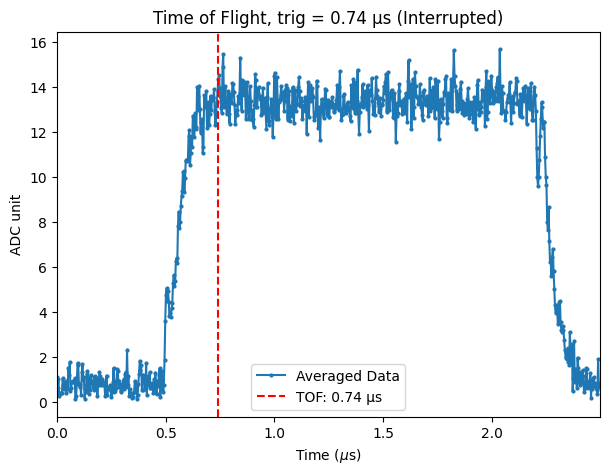

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0401\s001_tof_Q1_004


In [117]:
from qick_workspace.newscrip.s001_time_of_flight import TOF

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    {
        # "res_freq_ge": 3400,
        "ro_length": 2.5,
        "res_length": 1.7,
        "res_gain_ge": 0.18,
        "res_ch": 0,
        "cheek_e": False,
        "check_f": True,
        "relax_delay": 100,
    }
)

tof = TOF(soc, soccfg, run_cfg)
tof.run(1000)
tof.saveLabber(qubit)


In [3]:
config_all.update("trig_time", 0.49, q_index=qubit)

# YOKO Setting

In [ ]:
# from qick_workspace.tools.YOKOGS200 import YOKOGS200
# import pyvisa

# rm = pyvisa.ResourceManager()
# yoko_connect = "USB0::0x0B21::0x0039::90ZB35281::INSTR"
# yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
# yoko.OutputOff()

## Current mode

In [8]:
# yoko.SetMode("current")
# yokocurrent = 1 * 1e-3
# yoko.SetCurrent(yokocurrent)
# yoko.GetValue()

## Voltage mode

In [ ]:
# yoko.SetMode("voltage")
# yoko_value = -12.6
# yoko.SetVoltage(yoko_value, _rampstep=1e-2)
# print(yoko.GetValue())
# yoko_value = yoko.GetValue()

# GE State

## Resonator OneTone

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.7213),
 'Qi': -2397,
 'Ql': 1091,
 'absQc': 749,
 'κ(MHz)': np.float64(6.16)}


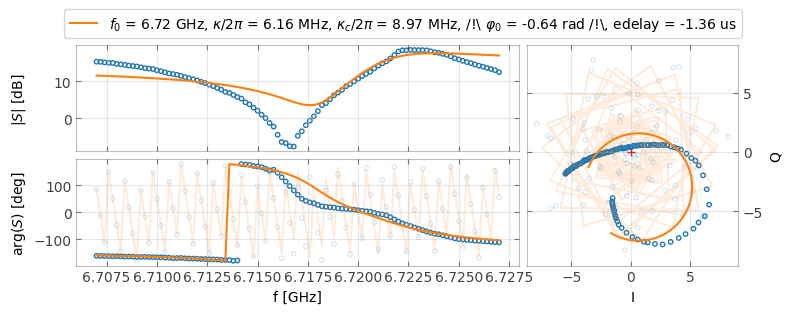

In [77]:
from qick_workspace.newscrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]


STEPS = 101

config_all.update("res.res_gain_ge", 0.1, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(soc, soccfg, run_cfg)
fres = onetone.run(py_avg=5, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

In [337]:
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0331\s002_onetone_ge_Q2_002


## OneTone PunchOut

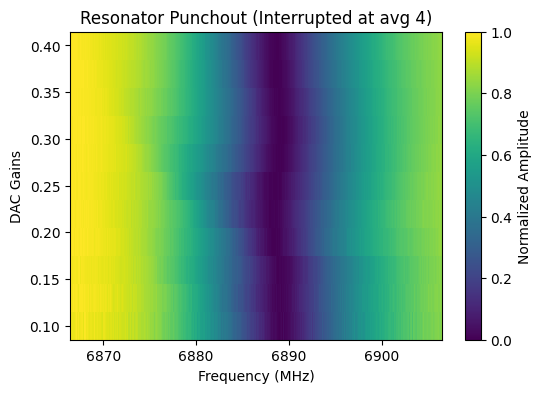

Experiment interrupted at 4 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s002b_res_ge_punchout_Q4_004


In [307]:
from qick_workspace.newscrip.s002b_res_punchout_ge import Punchout

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 20  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 20  # [MHz]



STEPS_freq = 101

START_gain = 0.1
STOP_gain = 0.4
STEPS_gain = 11

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("f_steps", STEPS_freq),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("g_steps", STEPS_gain),
        ("res_gain_ge", QickSweep1D("gainloop", START_gain, STOP_gain)),
        ("relax_delay", 0),
    ]
)
punchout = Punchout(soc, soccfg, run_cfg)
punchout.run(py_avg=100, show_final_plot=True)
punchout.saveLabber(qubit, config_all=config_all)

## Qubit Spectrum ge

Experiment interrupted at 19 averages. Fit is based on partial data.


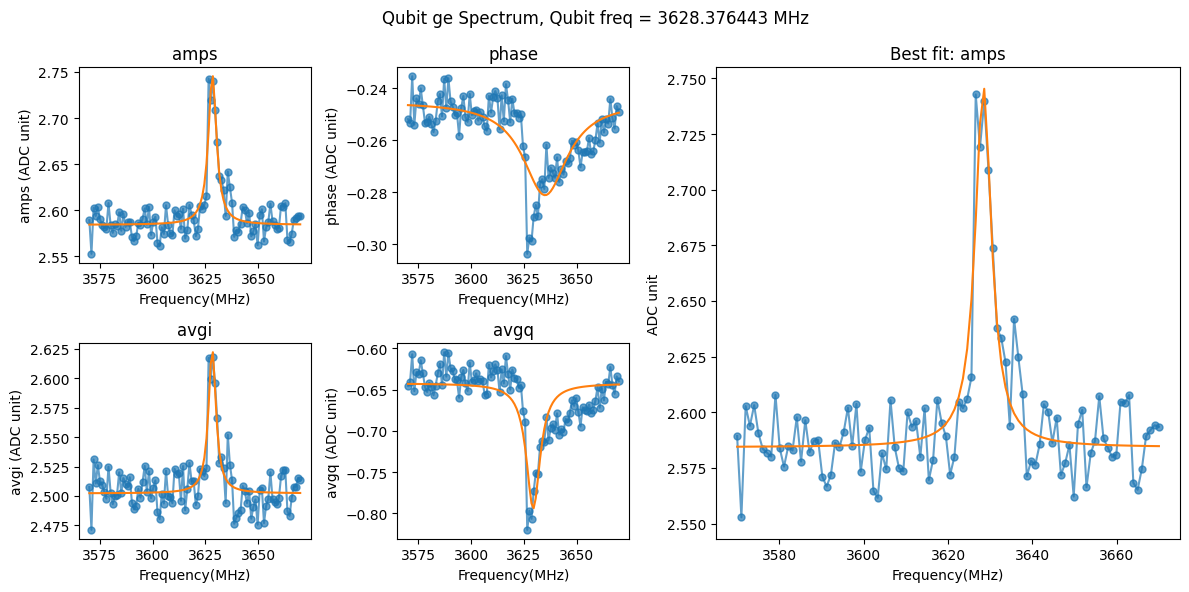

In [78]:
from qick_workspace.newscrip.s003_qubit_spec_ge import QubitSpec

center = 3620
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 100

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.01),
        ("qb_flat_top_length_ge", 1),
        ("relax_delay", 1),
        ("nqz_qb", 1),
    ]
)

spectrum_ge = QubitSpec(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(100)
config_all.update("qb.qb_freq_ge", f_ge, q_index=qubit)
config_all.update("qb.qb_mixer", f_ge, q_index=qubit)


In [237]:
spectrum_ge.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s003_qubit_spec_ge_Q2_003


### Fast flux spectrum

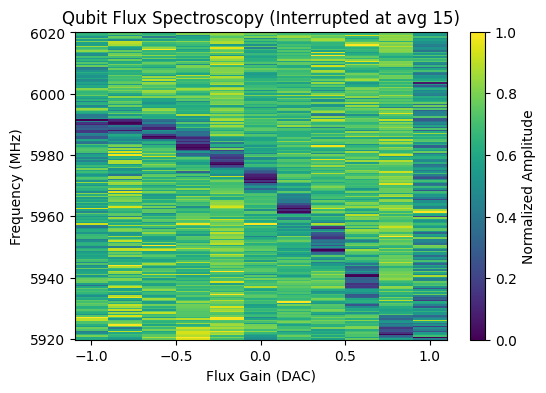

Experiment interrupted at 15 averages. Fit is based on partial data.


In [100]:
from qick_workspace.newscrip.s003a_qubit_flux_spec_ge import QubitSpecFlux

center = 5970
SPAN = 50
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 201

START_GAIN = -1
STOP_GAIN = 1
STEPS_GAIN = 11

config_all.update("ch.qb_ch", 2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_mixer", center),
        ("qb_gain_ge", 0.3),
        ("qb_flat_top_length_ge", 0.5),
        ("relax_delay", 1),
        ("nqz_qb", 2),
        ("res_length", 3),
        ("ro_length", 2.478),
        ("res_gain_ge", 0.95),
        ###################
        ("flux_ch", 15),
        ("flux_gain", QickSweep1D("fluxloop", START_GAIN, STOP_GAIN)),
        ("steps_flux", STEPS_GAIN),
        ("flux_length", 0.7),
    ]
)

spectrumff_ge = QubitSpecFlux(soc, soccfg, run_cfg)
spectrumff_ge.run(500, swap_xy=True, show_final_plot=True)


## Time Rabi ge

Experiment interrupted at 33 averages. Fit is based on partial data.


(np.float64(0.006415584088129531), np.float64(0.0019565014963671733))

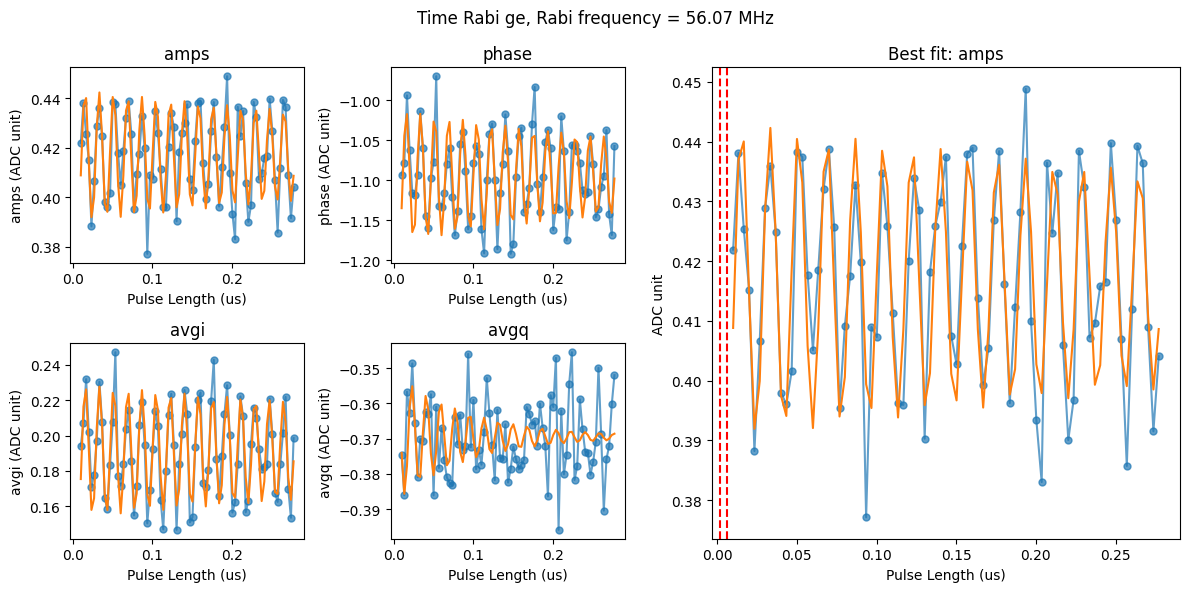

In [218]:
from qick_workspace.newscrip.s004_time_rabi_ge import TimeRabi


config_all.update("qb.sigma_ge", 0.01, q_index=qubit)
config_all.update("relax_delay", 50, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("cooling", False),
        ("qb_gain_ge", 0.5),
        ("qb_flat_top_length_ge", QickSweep1D("lenloop", 0.01, 0.3)),
        ("steps", 81),
    ]
)

Trabi = TimeRabi(soc, soccfg, run_cfg)
Trabi.run(100)
# Trabi.saveLabber(qubit, yoko_value=yoko_value)

## Power Rabi ge

Experiment interrupted at 9 averages. Fit is based on partial data.


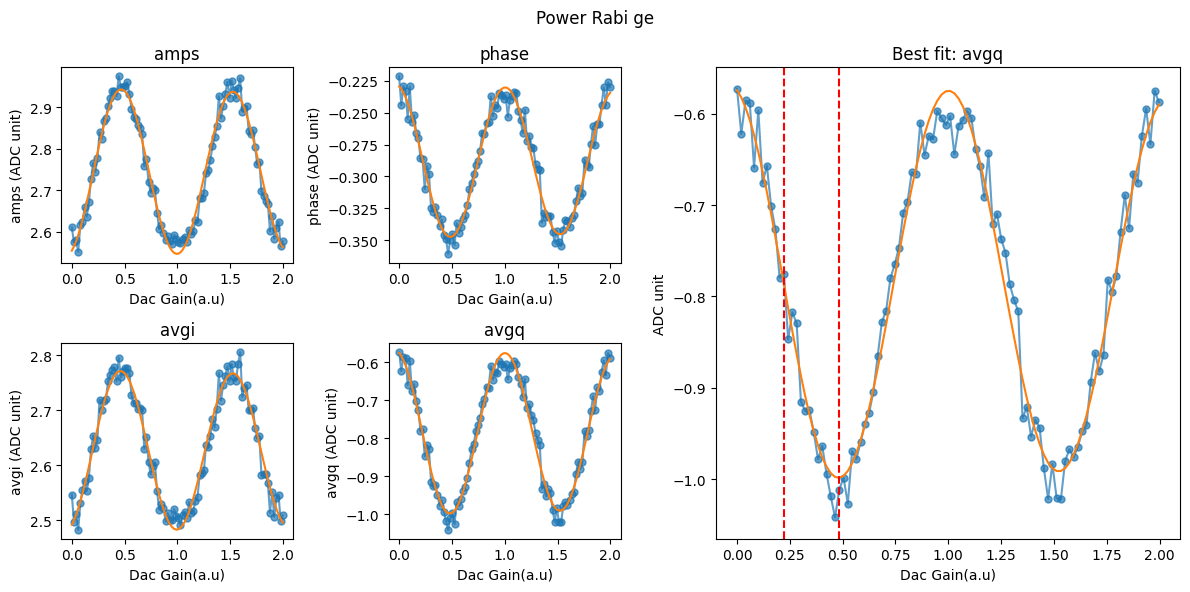

In [192]:
from qick_workspace.newscrip.s005_power_rabi_ge import PowerRabi

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 2  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ge", 0.005, q_index=qubit)
config_all.update("qb.nqz_qb", 1, q_index=qubit)
config_all.update("relax_delay", 400, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("pulse_type", "drag"),
        # ("qb_flat_top_length_ge", 0.1),
    ]
)

prabi = PowerRabi(soc, soccfg, run_cfg)
pi_gain, pi2_gain = prabi.run(20)
config_all.update("qb.pi_gain_ge", pi_gain, q_index=qubit)
config_all.update("qb.pi2_gain_ge", pi2_gain, q_index=qubit)

In [256]:
prabi.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s005_power_rabi_ge_Q3_004


In [ ]:
# from qick_workspace.newscrip.s005_power_rabi_ge_chevron import PowerRabiChevron

# START_GAIN = 0.0  # [DAC units]
# STOP_GAIN = 1  # [DAC units]
# STEPS = 100


# run_cfg = config_all.get_qubit(qubit)
# f_ge = run_cfg["qb_freq_ge"]
# run_cfg.update(
#     [
#         ("steps", STEPS),
#         ("qb_gain_ge", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
#         ("steps_freq", 11),
#         ("qb_freq_ge", QickSweep1D("freqloop", f_ge - 4, f_ge + 4)),
#     ]
# )


# prabi = PowerRabiChevron(soc, soccfg, run_cfg)
# prabi.run(py_avg=50)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_26448\346880547.py", line 1, in <module>
    from qick_workspace.newscrip.s005_power_rabi_ge_chevron import PowerRabiChevron
ModuleNotFoundError: No module named 'qick_workspace.newscrip.s005_power_rabi_ge_chevron'


## Amplified Amplitude Error (AAE)

Scan interrupted at average: 9


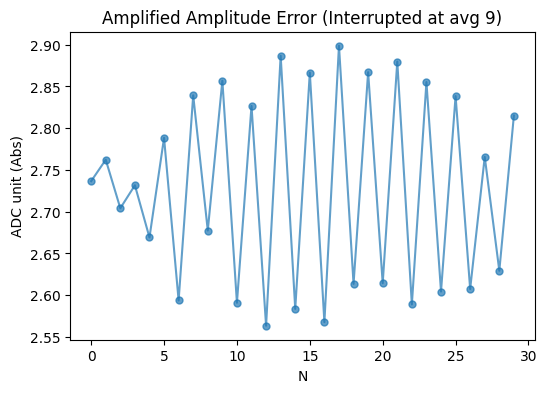

In [120]:
from qick_workspace.newscrip.s005a_AAE import AAE

run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("AAE", "pi2"),
    ]
)

aae = AAE(soc, soccfg, run_cfg)
aae.run(100, iteration_count=30)

## Ramsey ge

Experiment interrupted at 3 averages. Fit is based on partial data.


(array([ 0.20112148,  1.98358   , 61.46499661,  8.18989044,  2.75341257]),
 array([0.01233005, 0.01018595, 3.74870173, 3.94769205, 0.00418189]))

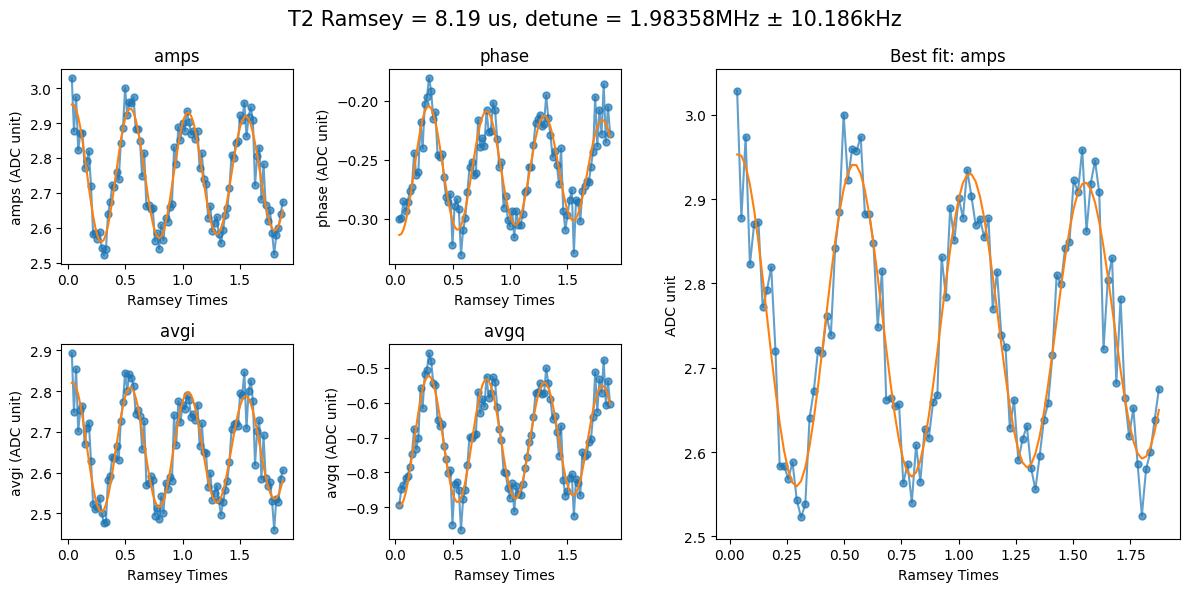

In [186]:
from qick_workspace.newscrip.s006_Ramsey_ge import Ramsey

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2 # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq",2),
        ("pulse_type", "drag"),
    ]
)

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(20)

In [187]:
config_all.update("qb.qb_freq_ge", t2r.correct_detune(), qubit)

over detune -0.01642MHz


In [243]:
t2r.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0330\s006_Ramsey_ge_Q2_001


In [96]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram

TAU_START = 0.01  # us
TAU_STOP = 0.2  # us


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", 81),
        ("flux_length", QickSweep1D("tloop", TAU_START, TAU_STOP)),
        ("flux_gain", 0.1),
        ("flux_ch", 15),
        ("relax_delay", 20),
    ]
)

prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result1 = prog.acquire(soc, rounds=30)


run_cfg["flux_gain"] = 0.5
prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result2 = prog.acquire(soc, rounds=20)

run_cfg["flux_gain"] = 1
prog = CryoscopeProgram(
    soccfg, reps=100, final_delay=run_cfg["relax_delay"], cfg=run_cfg
)
result3 = prog.acquire(soc, rounds=20)


# result = Cryoscope.run_xy(soc, soccfg, run_cfg, py_avg=50)
flux_len = prog.get_pulse_param("flux_pulse", "length", as_array=True)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_26448\3873301117.py", line 1, in <module>
    from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram
ModuleNotFoundError: No module named 'qick_workspace.newscrip.s010_cryoscope'


c:\Users\QEL\anaconda3\envs\qick2env\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\QEL\anaconda3\envs\qick2env\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Detuning')

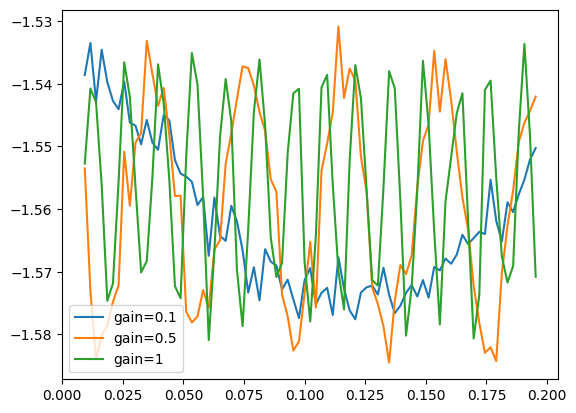

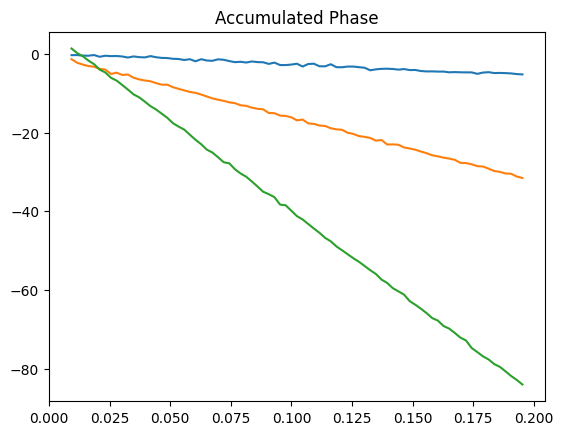

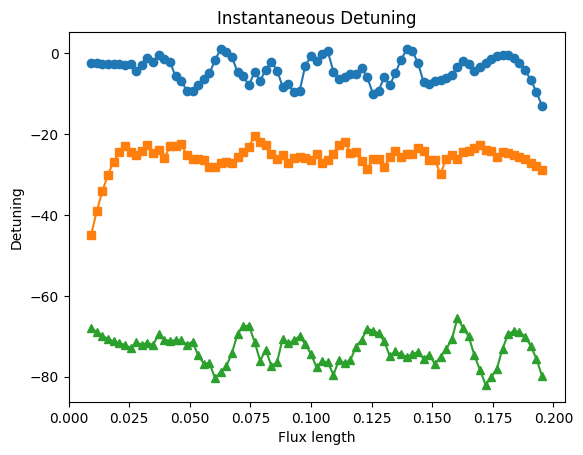

In [ ]:
X1 = result1[0][0].dot([1, 1j])
Y1 = result1[0][1].dot([1, 1j])
X2 = result2[0][0].dot([1, 1j])
Y2 = result2[0][1].dot([1, 1j])
X3 = result3[0][0].dot([1, 1j])
Y3 = result3[0][1].dot([1, 1j])

plt.plot(flux_len, X1, label="gain=0.1")
plt.plot(flux_len, X2, label="gain=0.5")
plt.plot(flux_len, X3, label="gain=1")
plt.legend()

X_centered1 = X1 - np.mean(X1)
Y_centered1 = Y1 - np.mean(Y1)
R1 = np.sqrt(X_centered1**2 + Y_centered1**2)
R1[R1 < 1e-6] = 1e-6
X_norm1 = X_centered1 / R1
Y_norm1 = Y_centered1 / R1
S1 = X_norm1 + 1j * Y_norm1
phase1 = np.unwrap(np.angle(S1))

X_centered2 = X2 - np.mean(X2)
Y_centered2 = Y2 - np.mean(Y2)
R2 = np.sqrt(X_centered2**2 + Y_centered2**2)
R2[R2 < 1e-6] = 1e-6
X_norm2 = X_centered2 / R2
Y_norm2 = Y_centered2 / R2
S2 = X_norm2 + 1j * Y_norm2
phase2 = np.unwrap(np.angle(S2))

X_centered3 = X3 - np.mean(X3)
Y_centered3 = Y3 - np.mean(Y3)
R3 = np.sqrt(X_centered3**2 + Y_centered3**2)
R3[R3 < 1e-6] = 1e-6
X_norm3 = X_centered3 / R3
Y_norm3 = Y_centered3 / R3
S3 = X_norm3 + 1j * Y_norm3
phase3 = np.unwrap(np.angle(S3))


plt.figure()
plt.plot(flux_len, phase1, label="gain=0.1")
plt.plot(flux_len, phase2, label="gain=0.5")
plt.plot(flux_len, phase3, label="gain=1")
plt.title("Accumulated Phase")


from scipy.signal import savgol_filter

dt = flux_len[1] - flux_len[0]

window_length = 13
polyorder = 3

phase_deriv1 = savgol_filter(phase1, window_length, polyorder, deriv=1)
freq1 = phase_deriv1 / dt / (2 * np.pi)

phase_deriv2 = savgol_filter(phase2, window_length, polyorder, deriv=1)
freq2 = phase_deriv2 / dt / (2 * np.pi)

phase_deriv3 = savgol_filter(phase3, window_length, polyorder, deriv=1)
freq3 = phase_deriv3 / dt / (2 * np.pi)

plt.figure()
plt.plot(flux_len, freq1, label="gain=0.1", marker="o")
plt.plot(flux_len, freq2, label="gain=0.5", marker="s")
plt.plot(flux_len, freq3, label="gain=1", marker="^")
plt.title("Instantaneous Detuning")
plt.xlabel("Flux length")
plt.ylabel("Detuning")

  0%|          | 0/50 [00:00<?, ?it/s]

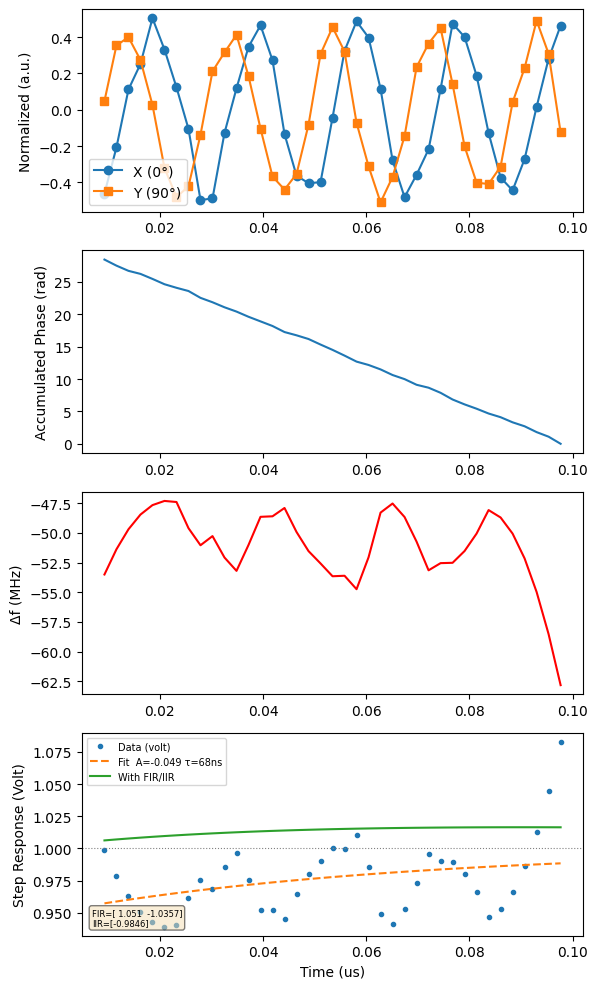

{'detuning': array([-53.50636094, -51.38147975, -49.69973682, -48.46113217,
        -47.66566577, -47.31333764, -47.40414778, -49.60710176,
        -51.04468609, -50.27397185, -52.0784764 , -53.19952236,
        -51.02046262, -48.65154615, -48.60735199, -47.90661776,
        -49.92728301, -51.53747939, -52.5764401 , -53.65401273,
        -53.61223423, -54.74421961, -52.05931648, -48.29677894,
        -47.53081   , -48.66790376, -50.73945588, -53.15395968,
        -52.55059904, -52.52131454, -51.52918315, -50.06135095,
        -48.08403684, -48.70759133, -50.06422933, -52.15395085,
        -54.97675589, -58.53264444, -62.82161651]),
 'step_response_freq': array([0.99787847, 0.95825003, 0.926886  , 0.90378638, 0.88895116,
        0.88238034, 0.88407392, 0.92515839, 0.95196893, 0.93759533,
        0.97124882, 0.99215601, 0.95151717, 0.90733755, 0.90651334,
        0.89344484, 0.93112968, 0.96115938, 0.98053571, 1.00063213,
        0.99985297, 1.02096418, 0.9708915 , 0.90072124, 0.88643613

In [ ]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope, CryoscopeProgram

TAU_START = 0.01  # us
TAU_STOP = 0.1  # us


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", 39),
        ("flux_length", QickSweep1D("tloop", TAU_START, TAU_STOP)),
        ("flux_gain", 0.8),
        ("flux_ch", 15),
        ("relax_delay", 20),
    ]
)

prog = Cryoscope(soc, soccfg, run_cfg)
prog.run_xy(soc, soccfg, run_cfg, py_avg=50)


Cryoscope PS Sweep: 100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


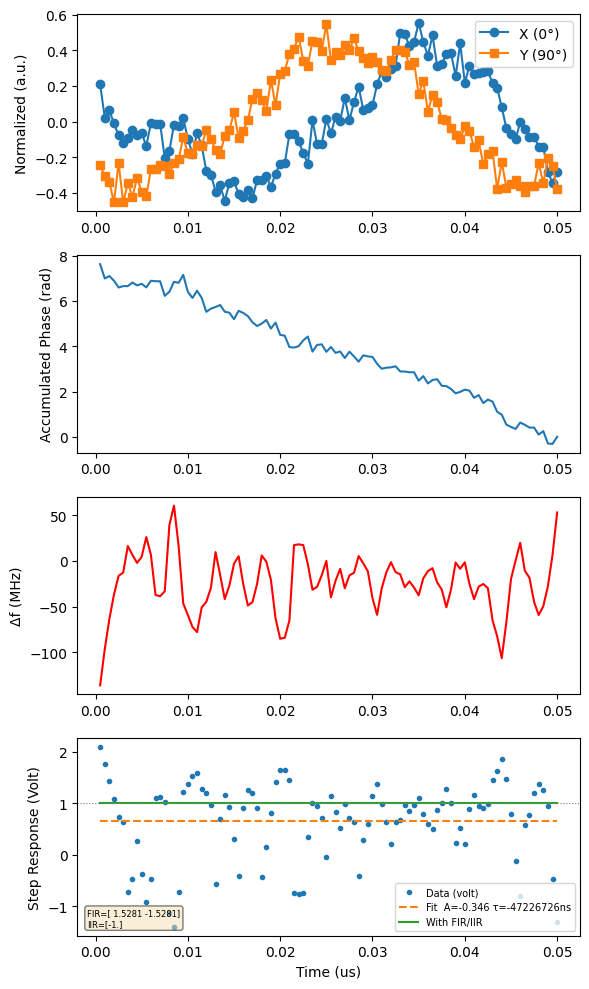

In [ ]:
from qick_workspace.newscrip.s010_cryoscope import Cryoscope


run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("flux_gain", 1),
        ("flux_ch", 15),
        ("relax_delay", 30),
    ]
)
times_ps = np.linspace(0.0005, 0.05, 100)
results = Cryoscope.run_ps(soc, soccfg, run_cfg, py_avg=30, times_us=times_ps)


## Spin Echo ge

Experiment interrupted at 6 averages. Fit is based on partial data.


(array([ 1.23024943e-01,  5.00663905e-02,  2.64453519e+02,  8.48007868e+01,
        -9.01030334e-01]),
 array([9.12251413e-03, 2.45621611e-04, 4.49097454e+00, 1.07146866e+01,
        2.31363297e-03]))

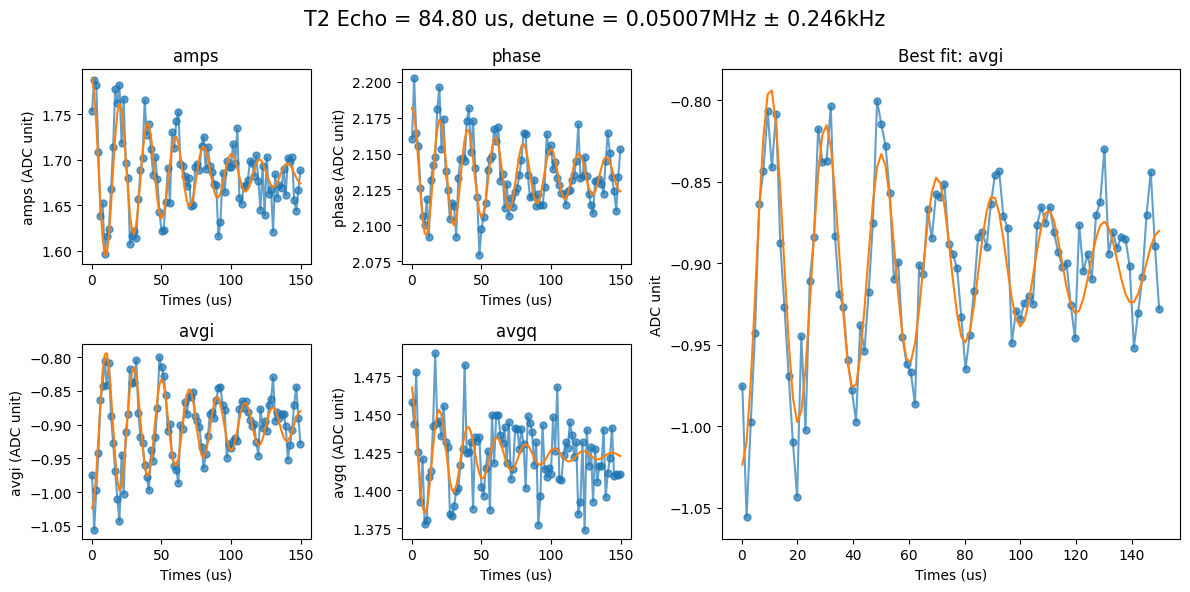

In [351]:
from qick_workspace.newscrip.s007_SpinEcho_ge import SpinEcho

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 150  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 0.05),
        # ("pulse_type", "drag")
    ]
)

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(100)

In [112]:
t2e.saveLabber(qubit, config_all=config_all, title="10mK")

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s007_SpinEcho_ge_Q1_10mK_002


## T1 ge

Experiment interrupted at 9 averages. Fit is based on partial data.


(array([ 2.59143748,  0.35197579, 50.47096867]),
 array([0.00474263, 0.00747636, 2.74971305]))

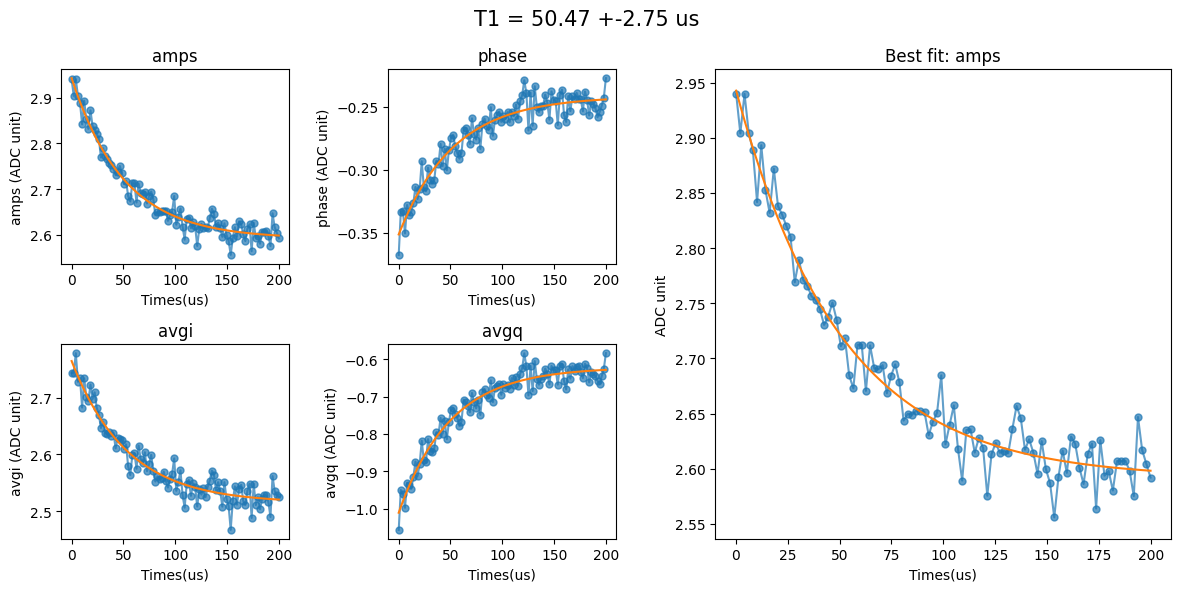

In [176]:
from qick_workspace.newscrip.s008_T1_ge import T1

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 200  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        # ('pulse_type', "drag"),
    ]
)

t1 = T1(soc, soccfg, run_cfg)
t1.run(50)

In [ ]:
t1.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s008_T1_ge_Q1_10mK_004


In [4]:
from qick_workspace.newscrip.s008_T1_ge_ff import T1FastFlux

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 10  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("relax_delay", 30),
        ### Flux Pulse ###
        ("steps_flux", 21),
        ("flux_length", 0.01 + QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("flux_gain", QickSweep1D("fluxloop", -1.0, 1.0)),
        ("flux_ch", 15),
    ]
)

t1 = T1FastFlux(soc, soccfg, run_cfg)
t1.run(30)

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_12476\2585222871.py", line 1, in <module>
    from qick_workspace.newscrip.s008_T1_ge_ff import T1FastFlux
ModuleNotFoundError: No module named 'qick_workspace.newscrip.s008_T1_ge_ff'


In [ ]:
t1.saveLabber(qubit, config_all=config_all)

2026-03-25 14:24:33,689 - SR_Network:BlockingClient - Error: Socket operation timed out


Data saved to c:\Users\QEL\Desktop\SQC_soc\test\2026\03\Data_0325\s008_T1_ff_ge_Q1_001


## Single Shot

  0%|          | 0/5000 [00:00<?, ?it/s]

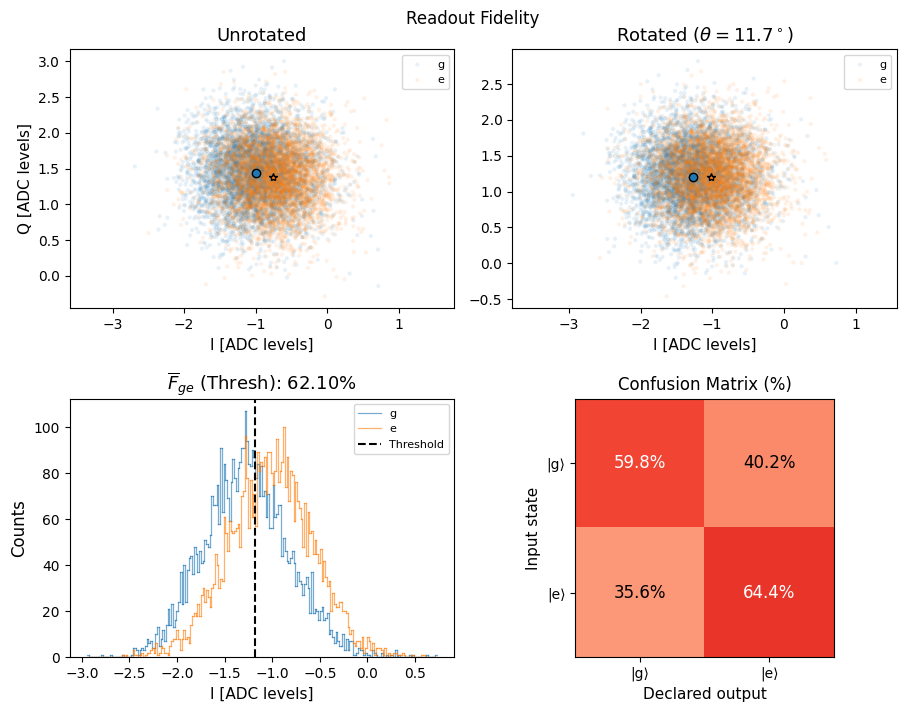

Theta: 11.72 deg
Threshold Fidelity: 62.100%
Confusion Matrix (%):
 [[59.8 40.2]
 [35.6 64.4]]
Current data file: D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0331\s000_singleshot_ge_Q3_010


In [350]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)


run_cfg['pulse_type'] = "drag"

SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=False)
ssh.plot(fid_avg=True, verbose=True, fit=False)
ssh.saveLabber(qubit)

In [348]:
from qick_workspace.newscrip.s000_SingleShot_opt import SingleShot_ge_opt
run_cfg = config_all.get_qubit(qubit)

run_cfg["res_length"] = 30
freq_axis = np.linspace(run_cfg["res_freq_ge"] - 3, run_cfg["res_freq_ge"] + 3, 6)
gain_axis = np.linspace(0.1, 0.3, 4)
length_axis = np.linspace(1, 8, 11)
run_cfg['pulse_type'] = "drag"
sweep_para = {"freq": run_cfg['res_freq_ge'], "gain": gain_axis, "length": length_axis}


SHOT = 1000
ssh_opt = SingleShot_ge_opt(soc, soccfg, run_cfg)
ssh_opt.run(SHOT, sweep_para=sweep_para)

Length loop:   0%|          | 0/11 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

...

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

Gain loop:   0%|          | 0/4 [00:00<?, ?it/s]

In [349]:
length, gain, freq = ssh_opt.analyze()
config_all.update("res.ro_length", length, q_index=qubit)
config_all.update("res.res_gain_ge", gain, q_index=qubit)
config_all.update("res.res_freq_ge", freq, q_index=qubit)
# config_all.update("res_phase", 164, q_index=qubit)
config_all.get_qubit(qubit)

Analyze max fidelity:   0%|          | 0/11 [00:00<?, ?it/s]


--- Grid Search Result ---
Max fidelity (on grid): 0.6505
At length=7.300 us, gain=0.10000 DAC, freq=6811.56390 MHz

--- Interpolated Result ---
Max fidelity (interpolated): 0.6589
At length=7.609 us, gain=0.10000 DAC, freq=6811.56390 MHz


{'name': 'Q3',
 'res_ch': 0,
 'qb_ch': 0,
 'qb_ch_ef': 0,
 'ro_ch': 0,
 'res_freq_ge': 6811.5639,
 'res_length': 10,
 'res_gain_ge': 0.1,
 'res_phase': 0,
 'res_sigma': 0.005,
 'ro_length': 7.609,
 'nqz_res': 2,
 'chi': False,
 'pulse_type': 'arb',
 'qb_freq_ge': 3127.99654,
 'qb_mixer': 3129.216543,
 'qb_gain_ge': 0.1,
 'qb_phase': 0,
 'sigma_ge': 0.02,
 'pi_gain_ge': 0.136804,
 'pi2_gain_ge': 0.067694,
 'qb_flat_top_length_ge': 0.1,
 'qb_freq_ef': 2907.84379,
 'qb_mixer_ef': 2908.603791,
 'qb_gain_ef': 0.1,
 'qb_phase_ef': 0,
 'sigma_ef': 0.01,
 'pi_gain_ef': 0.095725,
 'pi2_gain_ef': 0.047584,
 'qb_flat_top_length_ef': 0.1,
 'ramsey_freq': 2,
 'nqz_qb': 1,
 'nqz_qb_ef': 1,
 'cooling': False,
 'cool_ch1': 2,
 'cool_freq_1': 5400,
 'cool_gain_1': 0.1,
 'nqz_cool_ch1': 2,
 'cool_length': 100,
 'cool_ch2': 3,
 'cool_freq_2': 5400,
 'cool_gain_2': 0.1,
 'nqz_cool_ch2': 2,
 'reps': 100,
 'trig_time': 0.5,
 'relax_delay': 100}

# EF State

## Resonator OneTone ef

Experiment interrupted at 3 averages. Fit is based on partial data.


c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': np.float64(6.8116),
 'Qi': -28546,
 'Ql': 1286,
 'absQc': 1231,
 'κ(MHz)': np.float64(5.3)}


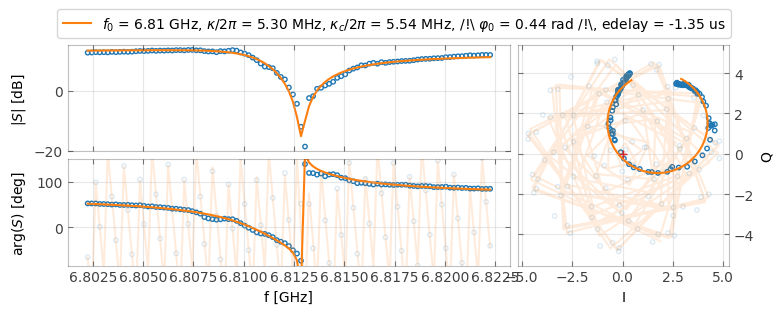

In [320]:
from qick_workspace.newscrip.s009_res_spec_ef import ResonatorSpec_ef

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
STEPS = 101

config_all.update("res.res_gain_ge", 0.2, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),

    ]
)

onetone_ef = ResonatorSpec_ef(soc, soccfg, run_cfg)
fres = onetone_ef.run(py_avg=20, solve_type="hm")
## update value ##
config_all.update("res.res_freq_ge", round(fres[0] / 1e6, 4), q_index=qubit)
# onetone_ef.saveLabber(qubit, yoko_value=yoko_value)

## Qubit Spectrum ef

Experiment interrupted at 5 averages. Fit is based on partial data.


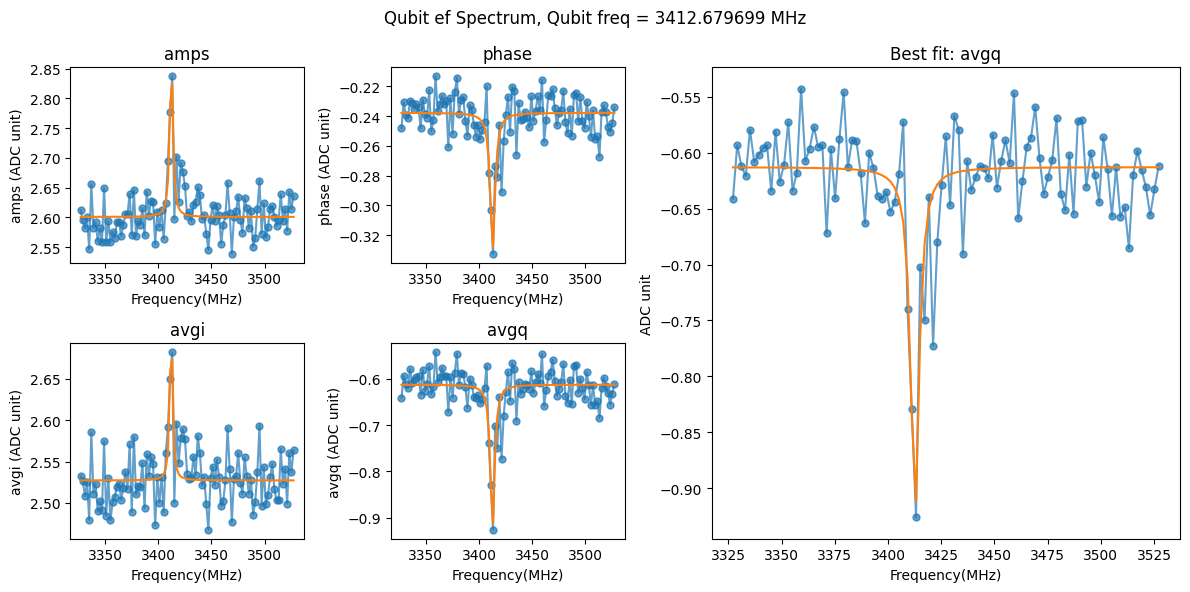

In [85]:
from qick_workspace.newscrip.s010_qubit_spec_ef import QubitSpec_ef

center = config_all.get_qubit(qubit)["qb_freq_ge"] - 200
SPAN = 100
START_FREQ = center - SPAN  # [MHz]
STOP_FREQ = center + SPAN  # [MHz]
STEPS = 101
config_all.update("ch.qb_ch_ef", 0, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)
run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_freq_ef", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("qb_gain_ef", 0.2),
        ("qb_flat_top_length_ef", 1),
        ("ge_ref", True),
    ]
)

spectrum_ef = QubitSpec_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ef.run(10)
config_all.update("qb.qb_freq_ef", f_ef, q_index=qubit)
config_all.update("qb.qb_mixer_ef", f_ef, q_index=qubit)
# spectrum_ef.saveLabber(qubit, yoko_value=yoko_value)

In [120]:
spectrum_ef.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s010_qubit_spec_ef_Q1_001


## Power Rabi ef

Experiment interrupted at 4 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0401\s011_power_rabi_ef_Q1_001


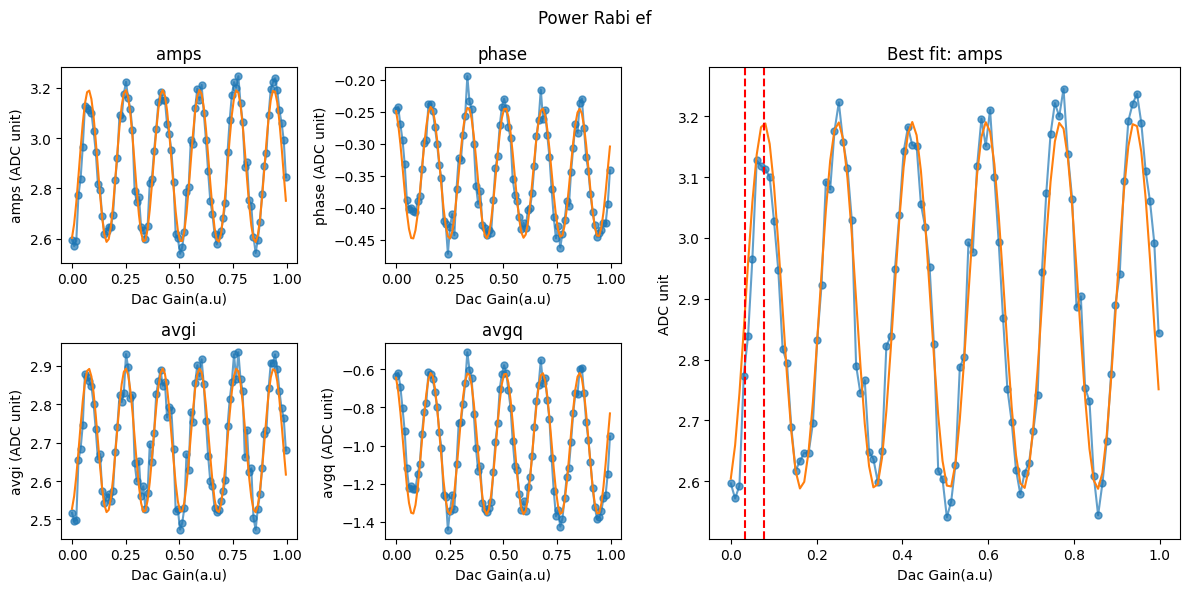

In [86]:
from qick_workspace.newscrip.s011_power_rabi_ef import PowerRabi_ef

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ef", 0.02, q_index=qubit)

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
    ]
)

prabi_ef = PowerRabi_ef(soc, soccfg, run_cfg)
pi_gain_ef, pi2_gain_ef = prabi_ef.run(500)
config_all.update("qb.pi_gain_ef", pi_gain_ef, q_index=qubit)
config_all.update("qb.pi2_gain_ef", pi2_gain_ef, q_index=qubit)
prabi_ef.saveLabber(qubit, config_all=config_all)

Experiment interrupted at 22 averages. Fit is based on partial data.
[Temp] A_meas=0.1249  A_ref=0.3824  ratio=3.0626
[Temp] Estimated temperature: 134.12 mK


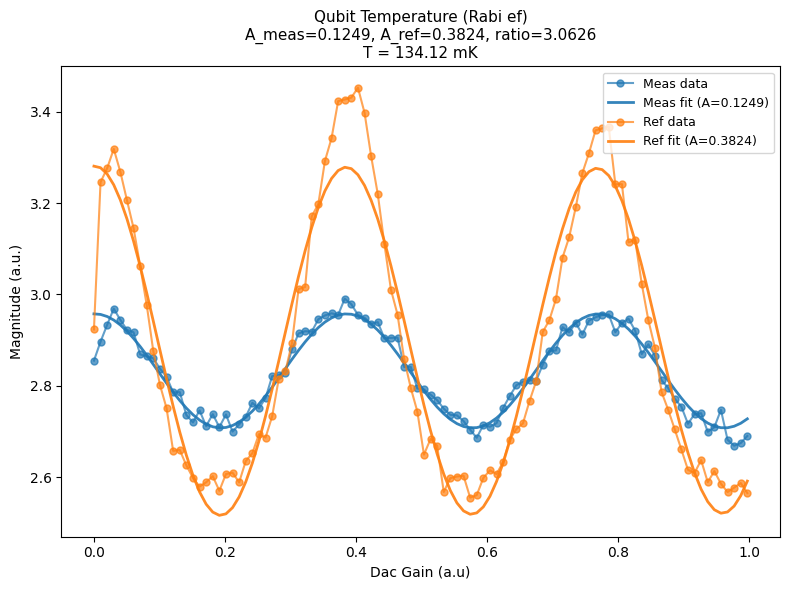

np.float64(0.1341230689531602)

In [343]:
from qick_workspace.newscrip.s013_qubit_temp import QubitTemperatureEf

START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config_all.update("qb.sigma_ef", 0.01, q_index=qubit)
config_all.update("relax_delay", 100, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("qb_gain_ef", QickSweep1D("gainloop", START_GAIN, STOP_GAIN)),
        ("ge_ref", True),
        ("ro_length", 2),
    ]
)
rabi_temp = QubitTemperatureEf(soc, soccfg, run_cfg)
rabi_temp.run(50)

In [123]:
rabi_temp.saveLabber(qubit, config_all=config_all)

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s013b_qubit_temp_ef_Q1_002


## Ramsey ef

Experiment interrupted at 3 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0401\s012_Ramsey_ef_Q1_001


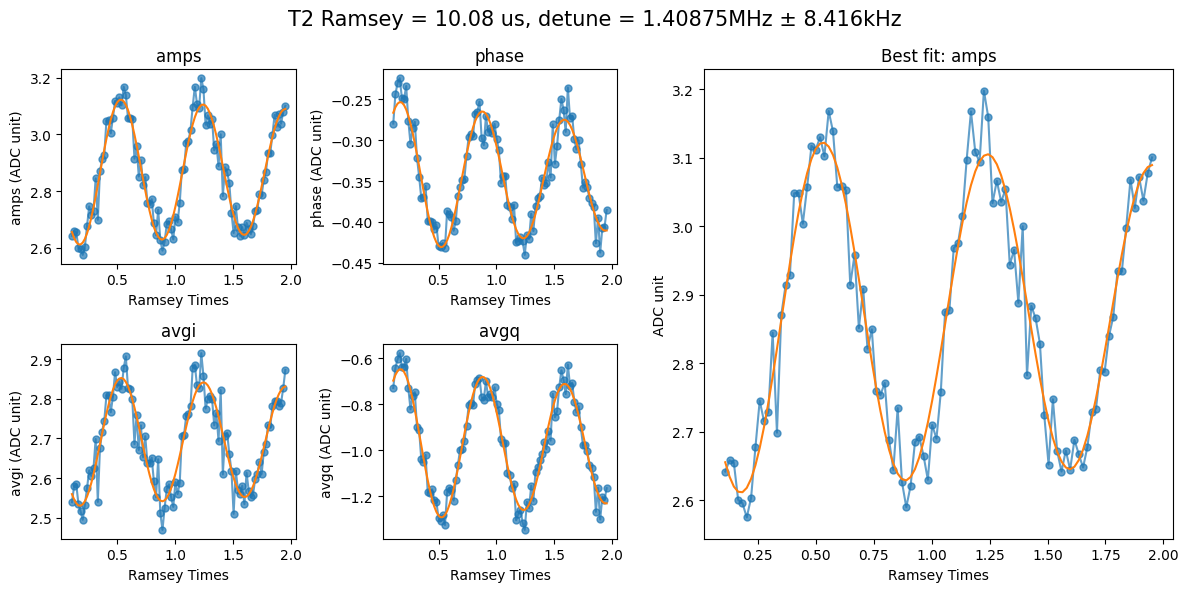

In [87]:
from qick_workspace.newscrip.s012_Ramsey_ef import Ramsey_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 2  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),
        ("ramsey_freq", 2),
        ("ge_ref", True),

    ]
)

t2r_ef = Ramsey_ef(soc, soccfg, run_cfg)
t2r_ef.run(100)
t2r_ef.saveLabber(qubit, config_all=config_all)

In [88]:
config_all.update("qb.qb_freq_ef", t2r_ef.correct_detune(), qubit)

over detune -0.59125MHz


## T1 ef

Experiment interrupted at 4 averages. Fit is based on partial data.
Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\2026\03\Data_0328\s013_T1_ef_Q3_001


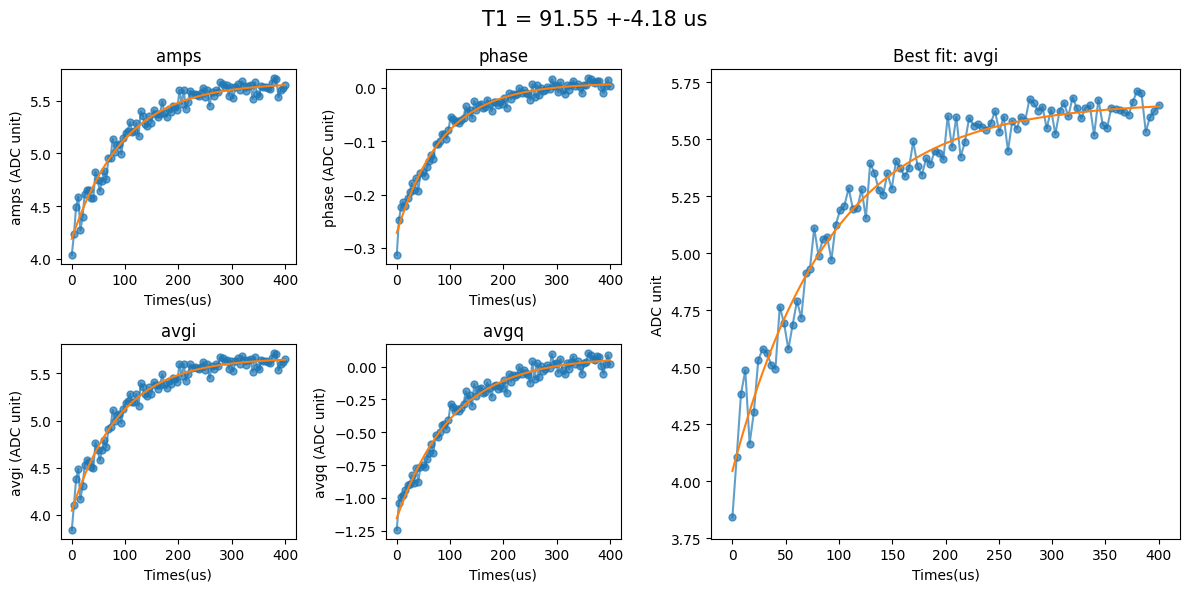

In [76]:
from qick_workspace.newscrip.s013_T1_ef import T1_ef

run_cfg = config_all.get_qubit(qubit)

START_TIME = 0.0  # [us]
STOP_TIME = 400  # [us]
STEPS = 100
run_cfg.update(
    [
        ("steps", STEPS),
        ("wait_time", QickSweep1D("waitloop", START_TIME, STOP_TIME)),

    ]
)

t1_ef = T1_ef(soc, soccfg, run_cfg)
t1_ef.run(50)
t1_ef.saveLabber(qubit, config_all=config_all)

## Single Shot gef

  0%|          | 0/5000 [00:00<?, ?it/s]

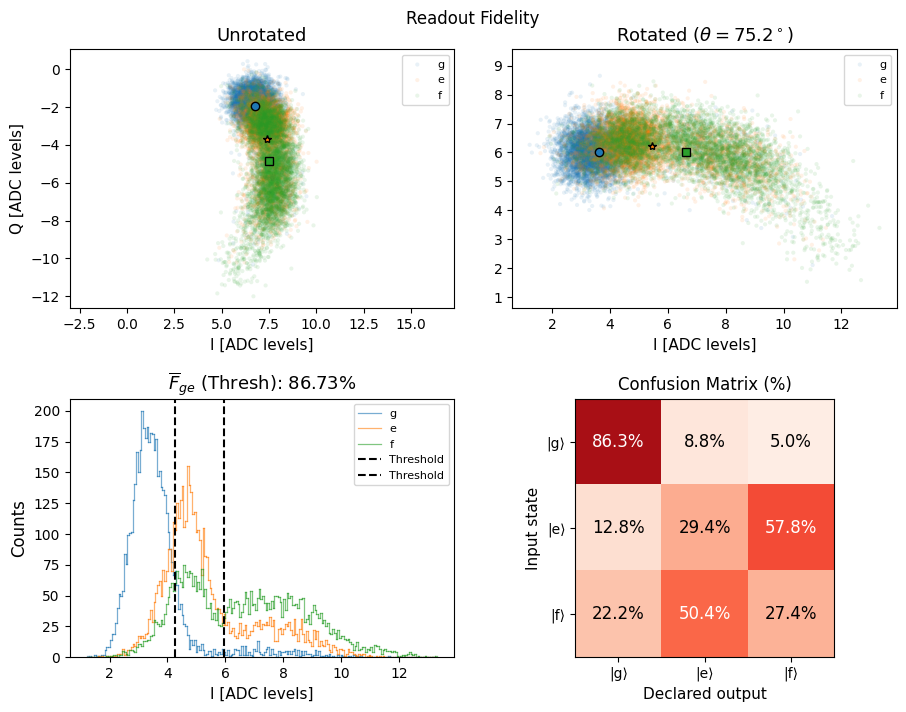

Theta: 75.19 deg
Threshold Fidelity: 86.730%
Confusion Matrix (%):
 [[86.26  8.76  4.98]
 [12.8  29.38 57.82]
 [22.18 50.4  27.42]]


[[np.float64(0.8673)],
 [np.float64(4.24714592991733), np.float64(5.939404465527091)],
 np.float64(75.19469870369264)]

In [124]:
from qick_workspace.newscrip.s000_SingleShot_prog import SingleShot_gef

run_cfg = config_all.get_qubit(qubit)


SHOT = 5000
ssh = SingleShot_gef(soc, soccfg, run_cfg)
ssh.run(SHOT, shot_f=True)
ssh.plot(fid_avg=True, verbose=True, fit=False)

# AllXY

AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

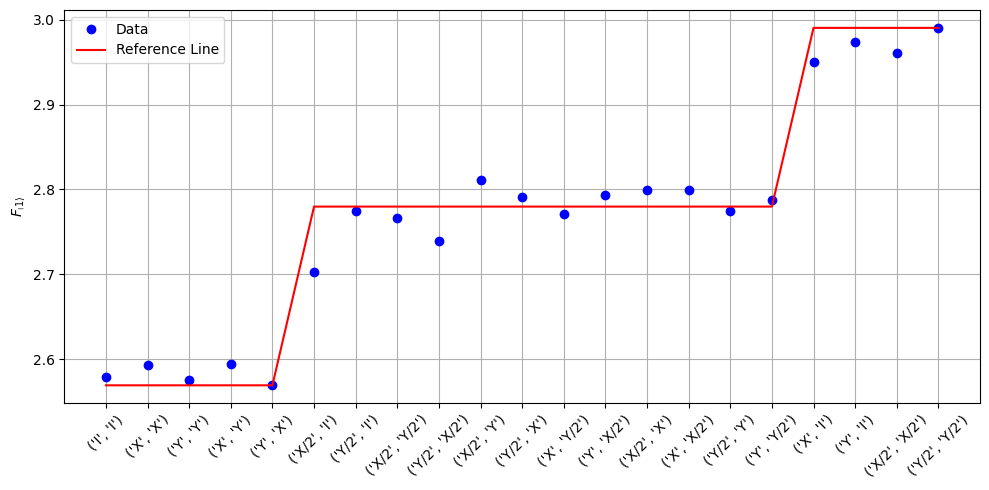

In [191]:
from qick_workspace.newscrip.s014_AllXY import AllXY

run_cfg = config_all.get_qubit(qubit)
run_cfg['relax_delay'] = 400
run_cfg.update([
    ("pulse_type", "drag"),
])
allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(10)
allxy.plot()

# State Tomography

Calibrating |0⟩ state...
Calibrating |1⟩ state...
IQ Ground: (-1.2314772135416665-0.56812890625j), IQ Excited: (-1.0361204427083335-0.3239713541666666j)


Tomography (x90):   0%|          | 0/3 [00:00<?, ?it/s]


<X>=-0.1786, <Y>=-1.0000, <Z>=-0.0206
Purity: 1.00000


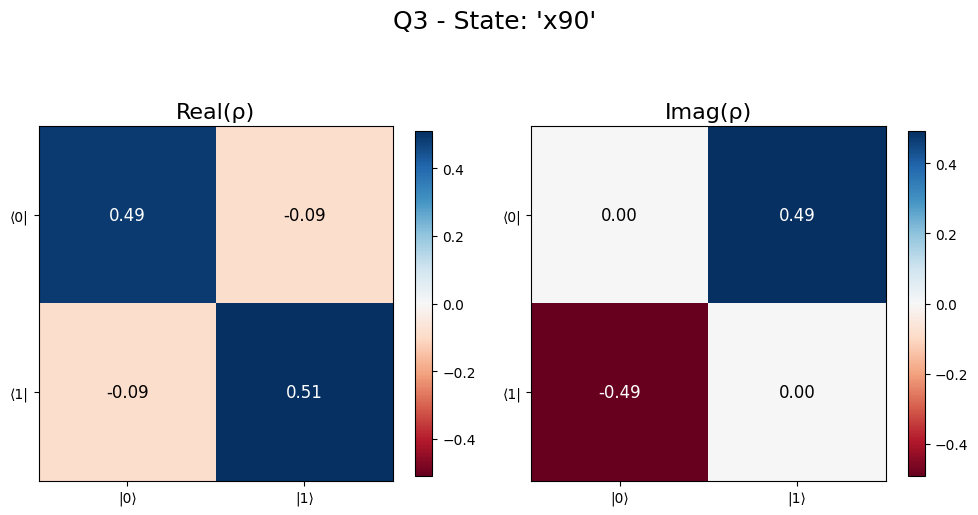

c:\Users\cluster\Desktop\SQC_soc-dev_mux\qick_workspace\newscrip\s016_state_tomography.py:216: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


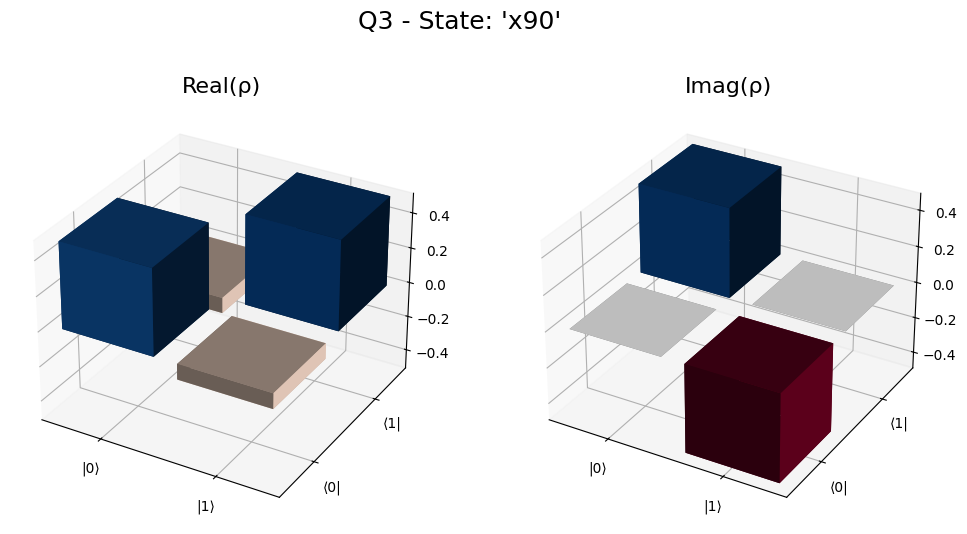

(<Figure size 1200x600 with 2 Axes>, None)

In [ ]:
from qick_workspace.newscrip.s016_state_tomography import Tomography

pyavg = 30

run_cfg = config_all.get_qubit(qubit)

tomo = Tomography(soc, soccfg, run_cfg)

tomo.run(py_avg=pyavg, prep_pulse_name="x90")

tomo.plot(plot_type="2d", qb_idx=3)
tomo.plot(plot_type="3d", qb_idx=3)

# Randomized Benchmarking


--- Running Standard RB (Ref) ---


Standard RB depth:   0%|          | 0/20 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

[fitrb] p=0.991984  a=-0.2000  b=2.7496
[fitrb] σ(p)=1.07e-03  σ(a)=1.20e-02  σ(b)=5.58e-03

--- Ref ---
  p   = 99.198414 ± 0.107329 %
  EPC = 0.400793 ± 0.053665 %
RB data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0401\s015_RB_Q1_ref_001


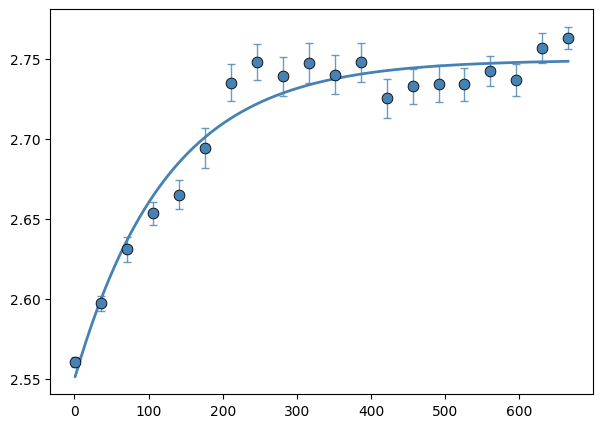

In [194]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
run_cfg['pulse_type'] = "drag"
run_cfg['res_length'] = 4
run_cfg['ro_length'] = 2.5
run_cfg['relax_delay'] = 400
py_avg = 15
max_circuit_depth = 700
delta_clifford = 35
number_sample = 40

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
    interleaved_gate=None,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
rb_exp_ref.saveLabber(qubit, config_all=config_all)

## Interleaved RB

In [ ]:
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
    rb_exp_irb.saveLabber(qubit, config_all=config_all)


--- Running Interleaved RB (X) ---


Interleaved RB (X) depth:   0%|          | 0/20 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

Samples:   0%|          | 0/40 [00:00<?, ?it/s]

[fitrb] p=0.994031  a=-0.2012  b=2.7781
[fitrb] σ(p)=1.83e-03  σ(a)=2.33e-02  σ(b)=1.71e-02

--- Reference ---
  p   = 99.403101 ± 0.183056 %
  EPC = 0.298449 ± 0.091528 %
[fitrb] p=0.993172  a=-0.1982  b=2.7784
[fitrb] σ(p)=1.52e-03  σ(a)=1.75e-02  σ(b)=1.12e-02

--- IRB  X ---
  p   = 99.317205 ± 0.152346 %
  EPC = 0.341398 ± 0.076173 %
[fitrb] p=0.986278  a=-0.1891  b=2.7753
[fitrb] σ(p)=5.59e-03  σ(a)=3.22e-02  σ(b)=1.27e-02

--- IRB  X/2 ---
  p   = 98.627800 ± 0.558643 %
  EPC = 0.686100 ± 0.279322 %
[fitrb] p=0.991832  a=-0.1976  b=2.7675
[fitrb] σ(p)=2.15e-03  σ(a)=2.16e-02  σ(b)=1.17e-02

--- IRB  Y ---
  p   = 99.183221 ± 0.215439 %
  EPC = 0.408390 ± 0.107719 %
[fitrb] p=0.989292  a=-0.1847  b=2.7533
[fitrb] σ(p)=1.94e-03  σ(a)=1.43e-02  σ(b)=6.39e-03

--- IRB  Y/2 ---
  p   = 98.929216 ± 0.193980 %
  EPC = 0.535392 ± 0.096990 %


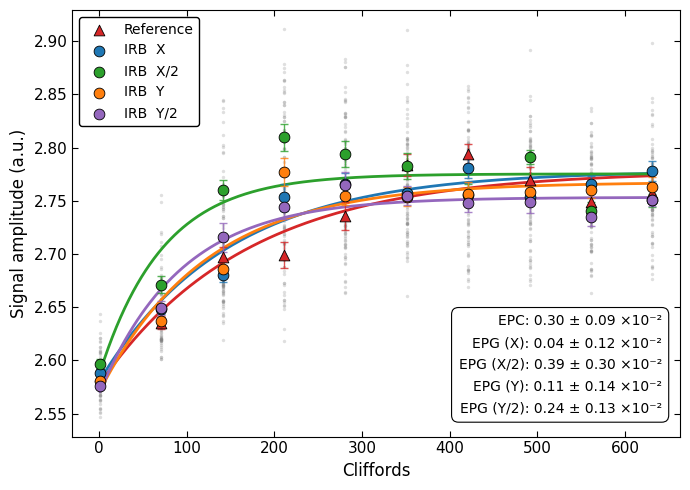


=== Gate Fidelities ===
  X       F = 99.9568 ± 0.1197 %
  X/2     F = 99.6100 ± 0.2955 %
  Y       F = 99.8894 ± 0.1421 %
  Y/2     F = 99.7616 ± 0.1339 %


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from qick_workspace.tools.fitting import rb_gate_fidelity

REF_COLOR  = "tab:red"
IRB_COLORS = ["tab:blue", "tab:green", "tab:orange", "tab:purple", "tab:cyan"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.8)
ax.tick_params(colors="black", labelsize=11, direction="in",
               top=True, right=True, length=4)
ax.grid(False)

# ── Reference RB ─────────────────────────────────────────────────────────────
epc_ref, epc_err_ref, p_ref, p_err_ref, pCov_ref = rb_exp_ref.plot(
    label="Reference", color=REF_COLOR,
    marker="^", ax=ax, show_individual=True,
)

# ── Interleaved RB ────────────────────────────────────────────────────────────
gate_results = {}
for i, (rb_exp_irb, gate) in enumerate(
    zip(all_rb_results[1:], interleaved_gates_to_test)
):
    c = IRB_COLORS[i % len(IRB_COLORS)]
    epc_irb, epc_err_irb, p_irb, p_err_irb, pCov_irb = rb_exp_irb.plot(
        label=f"IRB  {gate}", color=c,
        marker="o", ax=ax, show_individual=True,
    )
    fidelity = rb_gate_fidelity(p_ref, p_irb, d=2)
    fid_err  = rb_gate_fidelity_err(
        p_ref, p_irb,
        cov_p_rb=pCov_ref[0, 0], cov_p_irb=pCov_irb[0, 0], d=2,
    )
    gate_results[gate] = (fidelity, fid_err, c)

# ── Annotation box ────────────────────────────────────────────────────────────
ann_lines = [f"EPC: {epc_ref*100:.2f} ± {epc_err_ref*100:.2f} ×10⁻²"]
for gate, (fid, err, _) in gate_results.items():
    epg = 1 - fid
    ann_lines.append(f"EPG ({gate}): {epg*100:.2f} ± {err*100:.2f} ×10⁻²")
ann_text = "\n".join(ann_lines)

ax.text(0.97, 0.05, ann_text,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10, color="black",
        linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="white",
                  edgecolor="black",
                  linewidth=0.8))

# ── Labels & legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Cliffords", fontsize=12)
ax.set_ylabel("Signal amplitude (a.u.)", fontsize=12)
ax.legend(fontsize=10, frameon=True,
          framealpha=1.0, edgecolor="black",
          loc="upper left")

fig.tight_layout()
plt.show()

# ── Console summary ───────────────────────────────────────────────────────────
print("\n=== Gate Fidelities ===")
for gate, (fid, err, _) in gate_results.items():
    print(f"  {gate:6s}  F = {fid*100:.4f} ± {err*100:.4f} %")

# Nodrag

In [ ]:
from qick_workspace.newscrip.s015_Single_qubit_RB import RandomizedBenchmarking

run_cfg = config_all.get_qubit(qubit)
# run_cfg['pulse_type'] = "drag"
py_avg = 20
max_circuit_depth = 300
delta_clifford = 20
number_sample = 50

all_rb_results = []

print("\n--- Running Standard RB (Ref) ---")
rb_exp_ref = RandomizedBenchmarking(soc, soccfg, run_cfg)
rb_exp_ref.run(
    py_avg=py_avg,
    max_circuit_depth=max_circuit_depth,
    delta_clifford=delta_clifford,
    number_sample=number_sample,
    interleaved_gate=None,
)
rb_exp_ref.plot(label="Ref")

all_rb_results.append(rb_exp_ref)
## Interleaved RB
# interleaved_gates_to_test = ["X", "X/2", "-X/2", "Y", "Y/2", "-Y/2"]
interleaved_gates_to_test = ["X", "X/2", "Y", "Y/2"]

for gate in interleaved_gates_to_test:
    print(f"\n--- Running Interleaved RB ({gate}) ---")
    rb_exp_irb = RandomizedBenchmarking(soc, soccfg, run_cfg)
    rb_exp_irb.run(
        py_avg=py_avg,
        max_circuit_depth=max_circuit_depth,
        delta_clifford=delta_clifford,
        number_sample=number_sample,
        interleaved_gate=gate,
    )
    all_rb_results.append(rb_exp_irb)
import matplotlib.pyplot as plt
from qick_workspace.tools.fitting import rb_gate_fidelity

# Initialize a new plot to draw all curves together
plt.figure(figsize=(10, 7))

# 1. Plot the Reference (Standard RB) and get its fit parameters
# .plot() returns: (epc, epc_err, p_fit, p_fit_err)
epc_ref, epc_err_ref, p_ref, p_err_ref = rb_exp_ref.plot(label="Ref (Standard RB)", color='black')

gate_fidelities = {}

# 2. Loop through the interleaved results to plot them and calculate fidelities
# note: all_rb_results[1:] contains the IRB experiments
for rb_exp_irb, gate in zip(all_rb_results[1:], interleaved_gates_to_test):
    
    # Plot the interleaved curve right on top of the reference
    epc_irb, epc_err_irb, p_irb, p_err_irb = rb_exp_irb.plot(label=f"IRB ({gate})")
    
    # Calculate gate fidelity using the standard and interleaved p parameters
    # d = 2 for a single-qubit system
    fidelity = rb_gate_fidelity(p_ref, p_irb, d=2)
    gate_fidelities[gate] = fidelity

# 3. Format and display the combined plot
plt.xlabel("Number of Cliffords (Depth)")
plt.ylabel("Sequence Fidelity")
plt.title("Standard & Interleaved Randomized Benchmarking")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Print out the calculated single-qubit gate fidelities
print("\n=== Single-Qubit Interleaved Gate Fidelities ===")
for gate, fid in gate_fidelities.items():
    print(f"Gate {gate:5s} Fidelity: {fid * 100:.4f}%")


# Drag


[DRAG Sum] Optimal α = 0.499981)


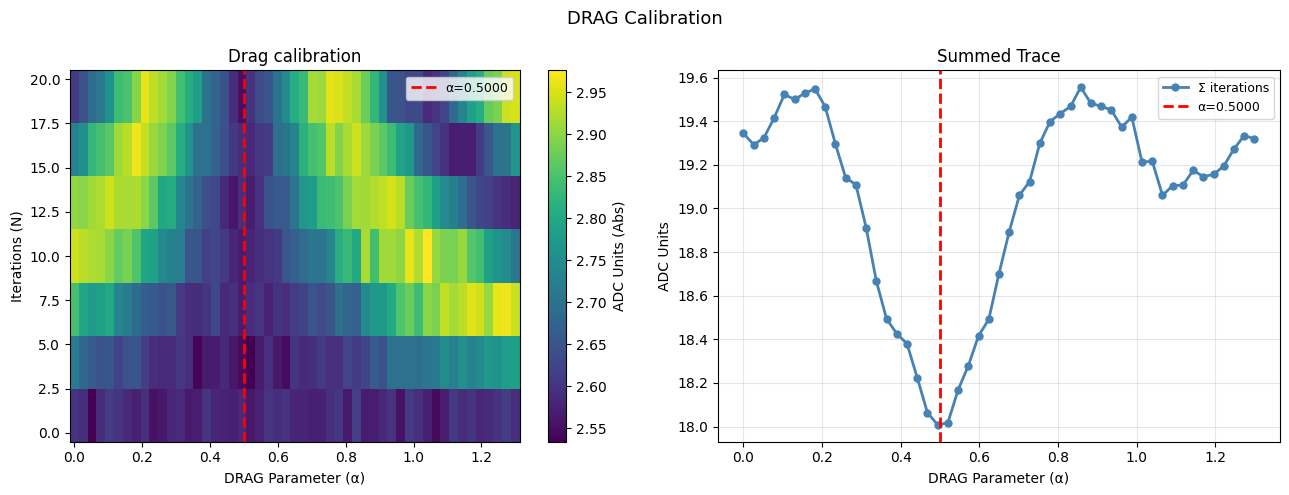

Data saved to D:\Labber_Data\Jay\purcell_tmon\Rshield\temperature\2026\04\Data_0401\s005a_drag_ge_Q1_003


In [189]:
from qick_workspace.newscrip.s005a_drag import DragCalibration

run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        # Alpha
        ("alpha_start", 0.0),
        ("alpha_stop", 1.3),
        ("alpha_steps", 51), 
        # Iterationi
        ("iter_start", 1),
        ("iter_stop", 20),
        ("iter_step", 3),
    ]
)

drag_cal = DragCalibration(soc, soccfg, run_cfg)
fit_results = drag_cal.run(py_avg=10)


config_all.update("qb.drag_alpha", fit_results['optimal_alpha'], q_index=qubit)

drag_cal.saveLabber(qubit, config_all=config_all)

In [64]:
config_all.update("qb.drag_alpha", fit_results['optimal_alpha'], q_index=qubit)

config_all.unified_config

{'name': ['Q1', 'Q2', 'Q3', 'Q4'],
 'res_ch': [0, 0, 0, 0],
 'qb_ch': [0, 0, 0, 0],
 'qb_ch_ef': [2, 2, 0, 2],
 'ro_ch': [0, 0, 0, 0],
 'res_freq_ge': [6717, 6740, 6811.7809, 6890],
 'res_length': 10,
 'res_gain_ge': [0.2, 0.1, 0.1, 0.1],
 'res_phase': [0, 0, 0, 0],
 'res_sigma': [0.005, 0.005, 0.005, 0.005],
 'ro_length': 5,
 'nqz_res': [2, 2, 2, 2],
 'chi': [False, False, False, False],
 'pulse_type': ['arb', 'arb', 'arb', 'arb'],
 'qb_freq_ge': [2872.649825, 3620.80596, 3127.9885, 3312.01532],
 'qb_mixer': [2872.649825, 3620.80596, 3132.778496, 3312.01532],
 'qb_gain_ge': [0.1, 0.1, 0.1, 0.1],
 'qb_phase': [0, 0, 0, 0],
 'sigma_ge': [0.05, 0.05, 0.005, 0.05],
 'pi_gain_ge': [0.1, 0.1, 0.524455, 0.1],
 'pi2_gain_ge': [0.1, 0.1, 0.24881, 0.1],
 'qb_flat_top_length_ge': [0.1, 0.1, 0.1, 0.1],
 'qb_freq_ef': [4000, 4000, 2907.29489, 4000],
 'qb_mixer_ef': [4000, 4000, 2907.494891, 4000],
 'qb_gain_ef': [0.1, 0.1, 0.1, 0.1],
 'qb_phase_ef': [0, 0, 0, 0],
 'sigma_ef': [0.05, 0.05, 0.02, 0.